# ExplainPlan-Vision
## Phase 1: Vision Foundation System


**Project:** ExplainPlan-Vision — Explainable Neuro-Symbolic Visual Planning Agent  
**Phase:** 1 of 7 — Vision Foundation  
**Dataset:** PlantVillage  
**Author:** Muhammad Aqib Javed  
**Date:** 2026

### Phase Overview

This notebook implements the **Vision Foundation System** — the perceptual backbone of ExplainPlan-Vision. Rather than building a simple image classifier, we are constructing a **modular perception module** designed to interface with:

- **Phase 2:** Grad-CAM / SHAP Explainability Layer  
- **Phase 3:** Sequential Planning Engine  
- **Phase 4:** Neuro-Symbolic Reasoning  
- **Phase 5:** Human-Aware Explanation Adaptation  

Every design decision in this notebook is made with those future phases in mind.

### System Pipeline

```
Image Input
    ↓
Augmentation Pipeline (Albumentations)
    ↓
Backbone Feature Extractor (EfficientNet-B0 / ResNet50)
    ↓
Classifier Head
    ↓
Structured Prediction Output
    {disease, confidence, severity, feature_embedding}
    ↓
→ Planning Engine (Phase 3)
→ Explainability Engine (Phase 2)
```

### Phase 1 Objectives

| # | Objective | Status |
|---|-----------|--------|
| 1 | Train disease classifier on PlantVillage | |
| 2 | Multi-backbone support (EfficientNet, ResNet) | |
| 3 | Structured prediction output with confidence | |
| 4 | Feature embedding extraction | |
| 5 | Heuristic severity estimation | |
| 6 | Mixed-precision training | |
| 7 | Early stopping + best checkpoint saving | |
| 8 | Full evaluation (F1, precision, recall, confusion matrix) | |
| 9 | Research-ready inference pipeline | |

## Cell 1 — Install Dependencies

We install only what is needed for Phase 1. Additional libraries (SHAP, LIME, LangChain) will be added in later phases.

In [9]:
!pip install -q albumentations timm torchmetrics

---
## Cell 2 — Imports

All imports are grouped by function. This makes the dependency graph clear for reviewers and future contributors.

In [11]:
# Standard Library
import os
import json
import time
import random
import warnings
from pathlib import Path
from copy import deepcopy

# Numerical / Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Image Processing
import cv2
from PIL import Image

# Progress
from tqdm.auto import tqdm

# PyTorch Core
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast

# Augmentations
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Model Zoo
import timm

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")
print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")

PyTorch version  : 2.10.0+cu128
CUDA available   : True
GPU              : Tesla T4


---
## Cell 3 — Configuration System

All hyperparameters and paths are centralised in `CONFIG`. **Nothing is hardcoded** anywhere else in the notebook.

This design decision is critical:
- Reproducibility across machines and phases
- Easy ablation study setup (swap `model_name` to run ResNet50)
- Clean methodology section for the research paper

> **Note:** Update `dataset_path` to match your Kaggle input path.

In [16]:
import os

CONFIG = {

    # Reproducibility
    "seed": 42,

    # Hardware
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "mixed_precision": True,

    # Dataset — update this path to match your Kaggle input directory
    "dataset_path": "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage",
    "image_size": 224,
    "batch_size": 32,
    "num_workers": 2,
    "train_split": 0.80,
    "valid_split": 0.10,
    "test_split":  0.10,

    # Model — swap to "resnet50" for the comparison baseline experiment
    "model_name": "efficientnet_b0",
    "pretrained": True,
    "dropout": 0.3,
    "embedding_dim": 512,

    # Training
    "epochs": 15,
    "learning_rate": 1e-4,
    "weight_decay": 1e-5,
    "label_smoothing": 0.1,

    # Scheduler
    "scheduler": "cosine",
    "warmup_epochs": 2,

    # Early Stopping
    "patience": 5,

    # ImageNet normalisation stats
    "mean": [0.485, 0.456, 0.406],
    "std":  [0.229, 0.224, 0.225],

    # Output paths
    "checkpoint_dir":  "outputs/checkpoints",
    "log_dir":         "outputs/logs",
    "prediction_dir":  "outputs/predictions",

    # Severity thresholds — confidence-based heuristic for Phase 3
    "severity_thresholds": {
        "high":   0.85,
        "medium": 0.60,
        "low":    0.0
    }
}

# Suppress the Hugging Face unauthenticated request warning.
# timm downloads pretrained weights from HF Hub; this token is not required
# for public models but the warning appears unless the variable is set.
os.environ["HF_TOKEN"] = os.environ.get("HF_TOKEN", "")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Create output directories
for path in [CONFIG["checkpoint_dir"], CONFIG["log_dir"], CONFIG["prediction_dir"]]:
    os.makedirs(path, exist_ok=True)

print(f"CONFIG loaded")
print(f"  Device     : {CONFIG['device']}")
print(f"  Model      : {CONFIG['model_name']}")
print(f"  Epochs     : {CONFIG['epochs']}")
print(f"  Batch size : {CONFIG['batch_size']}")

CONFIG loaded
  Device     : cuda
  Model      : efficientnet_b0
  Epochs     : 15
  Batch size : 32


---
## Cell 4 — Reproducibility

Seeding every random number source ensures that any reviewer can reproduce your exact results — essential for a research paper.

In [17]:
def set_seed(seed: int) -> None:
    """Seed all random number generators for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(CONFIG["seed"])
print(f"Seed set to {CONFIG['seed']}")

Seed set to 42


---
## Cell 5 — Dataset Discovery & Analysis

We dynamically discover all classes from the directory structure. This makes the system dataset-agnostic — swapping PlantVillage for PlantDoc in Phase 2 requires zero code changes.

In [18]:
dataset_path = Path(CONFIG["dataset_path"])

# ── Dynamic class discovery ───────────────────────────────────────────────────
classes      = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}
NUM_CLASSES  = len(classes)

print(f"{NUM_CLASSES} classes discovered")
print("\nSample classes:")
for cls in classes[:8]:
    print(f"   {cls}")
print("   ...")

15 classes discovered

Sample classes:
   Pepper__bell___Bacterial_spot
   Pepper__bell___healthy
   Potato___Early_blight
   Potato___Late_blight
   Potato___healthy
   Tomato_Bacterial_spot
   Tomato_Early_blight
   Tomato_Late_blight
   ...


---
## Cell 6 — Build Metadata DataFrame

We build a structured DataFrame over the dataset. This becomes the backbone for:
- Stratified splitting
- Severity label augmentation (Phase 3)
- Explainability case selection (Phase 2)
- Logging and traceability

In [19]:
records = []

for cls in classes:
    cls_dir = dataset_path / cls
    for img_file in cls_dir.iterdir():
        if img_file.suffix.lower() in [".jpg", ".jpeg", ".png"]:

            # PlantVillage uses two naming conventions:
            #   "Tomato___Early_blight"  (triple underscore between plant and disease)
            #   "Tomato_healthy"         (single underscore, no disease suffix)
            if "___" in cls:
                parts   = cls.split("___", 1)
                plant   = parts[0].replace("_", " ").strip()
                disease = parts[1].replace("_", " ").strip()
            else:
                # Treat the full name as the plant; disease is "Healthy" or last token
                tokens  = cls.split("_")
                plant   = tokens[0].strip()
                disease = " ".join(tokens[1:]).strip() if len(tokens) > 1 else cls

            is_healthy = "healthy" in cls.lower()

            records.append({
                "image_path" : str(img_file),
                "label"      : cls,
                "label_idx"  : class_to_idx[cls],
                "plant"      : plant,
                "disease"    : disease,
                "is_healthy" : is_healthy
            })

df = pd.DataFrame(records)
print(f"Total images: {len(df)}")
print(f"  Healthy   : {df['is_healthy'].sum()}")
print(f"  Diseased  : {(~df['is_healthy']).sum()}")
print()
print(df.head(3).to_string(index=False))

Total images: 20638
  Healthy   : 3221
  Diseased  : 17417

                                                                                                                                        image_path                         label  label_idx        plant        disease  is_healthy
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/0f72db9c-d635-4415-9781-68937328aed2___NREC_B.Spot 9188.JPG Pepper__bell___Bacterial_spot          0 Pepper  bell Bacterial spot       False
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/1b8d3e98-43d9-441d-93ef-a359e6e9ddc2___NREC_B.Spot 9052.JPG Pepper__bell___Bacterial_spot          0 Pepper  bell Bacterial spot       False
  /kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/b6d35d21-4812-4e32-ab9a-b6ddda8cbb79___JR_B.Spot 8972.JPG Pepper__bell___Bacterial_spot          0 Pepper  bell Bacterial spot       False


---
## Cell 7 — Class Distribution Analysis

Understanding class imbalance is critical before training. An imbalanced dataset produces misleading accuracy scores — which is why we use F1 as the primary metric.

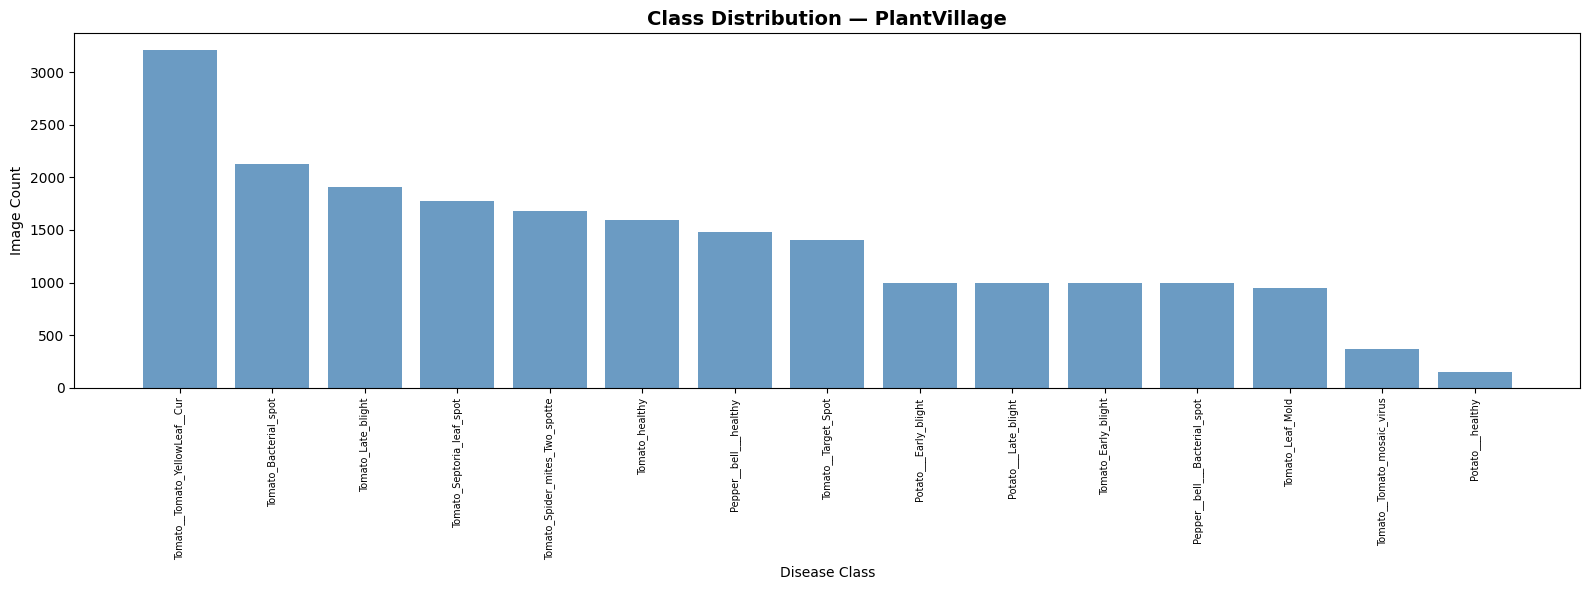

Min class size : 152
Max class size : 3208
Mean class size: 1376


In [20]:
class_counts = df["label"].value_counts().reset_index()
class_counts.columns = ["label", "count"]

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(range(len(class_counts)), class_counts["count"], color="steelblue", alpha=0.8)
ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels(
    [c[:30] for c in class_counts["label"]],
    rotation=90, fontsize=7
)
ax.set_title("Class Distribution — PlantVillage", fontsize=14, fontweight="bold")
ax.set_ylabel("Image Count")
ax.set_xlabel("Disease Class")
plt.tight_layout()
plt.savefig(f"{CONFIG['log_dir']}/class_distribution.png", dpi=150)
plt.show()

print(f"Min class size : {class_counts['count'].min()}")
print(f"Max class size : {class_counts['count'].max()}")
print(f"Mean class size: {class_counts['count'].mean():.0f}")

---
## Cell 8 — Stratified Train / Validation / Test Split

We use **stratified splitting** to ensure every class is proportionally represented in all three splits. This is essential for fair evaluation and is expected in any research paper.

In [21]:
# ── Step 1: split off (valid + test) from train ───────────────────────────────
train_df, temp_df = train_test_split(
    df,
    test_size=(1.0 - CONFIG["train_split"]),
    stratify=df["label"],
    random_state=CONFIG["seed"]
)

# ── Step 2: split temp into valid and test equally ───────────────────────────
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=CONFIG["seed"]
)

# Reset indices
train_df = train_df.reset_index(drop=True)
valid_df  = valid_df.reset_index(drop=True)
test_df   = test_df.reset_index(drop=True)

print("Stratified split complete")
print(f"   Train : {len(train_df):>6} images  ({len(train_df)/len(df)*100:.1f}%)")
print(f"   Valid : {len(valid_df):>6} images  ({len(valid_df)/len(df)*100:.1f}%)")
print(f"   Test  : {len(test_df):>6} images  ({len(test_df)/len(df)*100:.1f}%)")

Stratified split complete
   Train :  16510 images  (80.0%)
   Valid :   2064 images  (10.0%)
   Test  :   2064 images  (10.0%)


---
## Cell 9 — Augmentation Pipeline

Augmentations are designed to be **realistic** rather than aggressive. Reason: in Phase 2, Grad-CAM heatmaps must correspond to meaningful image regions. Extreme augmentations (elastic distortions, heavy color jitter) corrupt the spatial correlation that Grad-CAM depends on.

Training augmentations introduce controlled variation. Validation/test transforms are deterministic.

In [22]:
train_transforms = A.Compose([
    A.Resize(CONFIG["image_size"], CONFIG["image_size"]),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
    A.GaussNoise(var_limit=(10, 50), p=0.2),
    A.Normalize(mean=CONFIG["mean"], std=CONFIG["std"]),
    ToTensorV2()
])

valid_transforms = A.Compose([
    A.Resize(CONFIG["image_size"], CONFIG["image_size"]),
    A.Normalize(mean=CONFIG["mean"], std=CONFIG["std"]),
    ToTensorV2()
])

print("Augmentation pipelines ready")

Augmentation pipelines ready


---
## Cell 10 — Dataset Class

The `PlantDiseaseDataset` returns a **structured dictionary** rather than a bare `(image, label)` tuple. This design is intentional:

- Phase 2 needs `image_path` for Grad-CAM overlays
- Phase 3 needs `label_name` to look up the knowledge base
- Phase 5 needs metadata for user-adaptive explanations

Changing to a tuple return type later would break every downstream phase.

In [23]:
class PlantDiseaseDataset(Dataset):
    """
    Structured dataset for ExplainPlan-Vision.

    Returns a dict per sample so that downstream phases (explainability,
    planning, human-aware reasoning) can access image paths, class names,
    and metadata without coupling to positional tuple indices.
    """

    def __init__(self, dataframe: pd.DataFrame, transforms=None):
        self.df         = dataframe.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> dict:
        row = self.df.iloc[idx]

        # ── Load image ────────────────────────────────────────────────────────
        image = cv2.imread(row["image_path"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # ── Apply augmentations ───────────────────────────────────────────────
        if self.transforms:
            image = self.transforms(image=image)["image"]

        return {
            "image"      : image,
            "label"      : torch.tensor(row["label_idx"], dtype=torch.long),
            "label_name" : row["label"],
            "plant"      : row["plant"],
            "disease"    : row["disease"],
            "image_path" : row["image_path"]
        }

print("PlantDiseaseDataset class defined")

PlantDiseaseDataset class defined


---
## Cell 11 — DataLoaders

In [24]:
train_ds = PlantDiseaseDataset(train_df, transforms=train_transforms)
valid_ds = PlantDiseaseDataset(valid_df, transforms=valid_transforms)
test_ds  = PlantDiseaseDataset(test_df,  transforms=valid_transforms)

# num_workers=2 with pin_memory can trigger a thread-join error in certain
# Kaggle kernel configurations. Setting num_workers=0 runs loading in the
# main process and is completely stable; the GPU is the bottleneck anyway.
train_loader = DataLoader(
    train_ds, batch_size=CONFIG["batch_size"],
    shuffle=True, num_workers=0, pin_memory=True
)
valid_loader = DataLoader(
    valid_ds, batch_size=CONFIG["batch_size"],
    shuffle=False, num_workers=0, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=CONFIG["batch_size"],
    shuffle=False, num_workers=0, pin_memory=True
)

print(f"DataLoaders ready")
print(f"  Train batches : {len(train_loader)}")
print(f"  Valid batches : {len(valid_loader)}")
print(f"  Test  batches : {len(test_loader)}")

DataLoaders ready
  Train batches : 516
  Valid batches : 65
  Test  batches : 65


---
## Cell 12 — Sample Batch Visualisation

Always sanity-check the data pipeline before training. This catches augmentation bugs and path errors early.

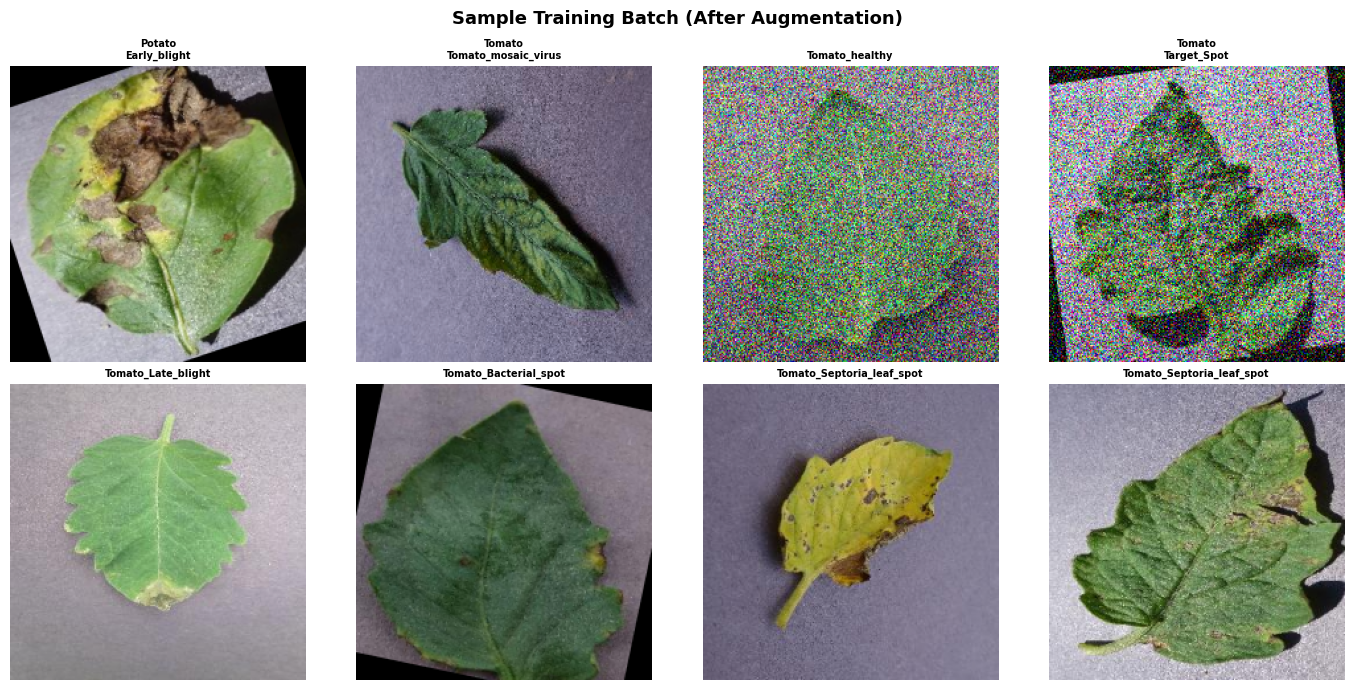

Batch shape: torch.Size([32, 3, 224, 224])


In [25]:
def denormalize(tensor, mean, std):
    """Reverse ImageNet normalisation for visualisation."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std  = torch.tensor(std).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

batch = next(iter(train_loader))
images, labels, names = batch["image"], batch["label"], batch["label_name"]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i], CONFIG["mean"], CONFIG["std"])
    img = img.permute(1, 2, 0).numpy()
    ax.imshow(img)
    title = names[i].replace("___", "\n").replace("__", "\n")
    ax.set_title(title[:35], fontsize=7, fontweight="bold")
    ax.axis("off")

plt.suptitle("Sample Training Batch (After Augmentation)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CONFIG['log_dir']}/sample_batch.png", dpi=150)
plt.show()
print(f"Batch shape: {images.shape}")

---
## Cell 13 — Model Architecture

### Design Rationale

The model is split into two components:

1. **`backbone`** — a pretrained feature extractor (EfficientNet-B0 or ResNet50), loaded via `timm` with `num_classes=0` so it returns raw feature vectors
2. **`classifier`** — a lightweight MLP head on top of the backbone features

**Why expose both `logits` and `features`?**  
The `features` tensor (the 1280-dim embedding from EfficientNet) will be used in:
- Phase 2: SHAP feature attribution requires access to intermediate representations
- Phase 3: The planner can use embedding similarity to find analogous past cases
- Phase 4: Neuro-symbolic reasoning uses embeddings as grounded symbol anchors

Hiding features inside a black-box `forward()` call would require rewriting the model in Phase 2.

In [26]:
class PlantDiseaseModel(nn.Module):
    """
    Modular perception backbone for ExplainPlan-Vision.

    Architecture
    ────────────
    Input image (3 × 224 × 224)
        → Pretrained backbone (EfficientNet-B0 / ResNet50)
        → Feature embedding  (embedding_dim)
        → Classifier head    (num_classes)
        → (logits, features)   ← Both returned for downstream phases
    """

    def __init__(self, model_name: str, num_classes: int,
                 embedding_dim: int = 512, dropout: float = 0.3):
        super().__init__()

        # ── Backbone: pretrained, no classification head ──────────────────────
        self.backbone = timm.create_model(
            model_name, pretrained=True, num_classes=0
        )
        backbone_out = self.backbone.num_features

        # ── Classifier head ───────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(backbone_out, embedding_dim),
            nn.BatchNorm1d(embedding_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(embedding_dim, num_classes)
        )

        self.embedding_dim = embedding_dim

    def forward(self, x: torch.Tensor):
        """
        Returns
        ───────
        logits   : (batch, num_classes) — raw classification scores
        features : (batch, backbone_out) — feature embedding for Phase 2/3/4
        """
        features = self.backbone(x)
        logits   = self.classifier(features)
        return logits, features

    def extract_features(self, x: torch.Tensor) -> torch.Tensor:
        """Convenience method — returns only the feature embedding."""
        with torch.no_grad():
            return self.backbone(x)


# ── Initialise ────────────────────────────────────────────────────────────────
model = PlantDiseaseModel(
    model_name    = CONFIG["model_name"],
    num_classes   = NUM_CLASSES,
    embedding_dim = CONFIG["embedding_dim"],
    dropout       = CONFIG["dropout"]
).to(CONFIG["device"])

# ── Parameter count ───────────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: {CONFIG['model_name']}")
print(f"   Total parameters     : {total_params:,}")
print(f"   Trainable parameters : {trainable_params:,}")
print(f"   Output classes       : {NUM_CLASSES}")

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Model: efficientnet_b0
   Total parameters     : 4,672,139
   Trainable parameters : 4,672,139
   Output classes       : 15


---
## Cell 14 — Loss, Optimiser, Scheduler

### Why Label Smoothing?

Label smoothing (`label_smoothing=0.1`) prevents the model from becoming **overconfident**. A model that outputs `confidence = 0.9999` is rarely trustworthy. Label smoothing produces better-calibrated probability estimates — which directly feeds the severity heuristic used by the Phase 3 planning engine.

### Why Cosine Annealing?

Cosine annealing with warmup allows the model to stabilise early (warmup) and then gradually reduce the learning rate, consistently outperforming step decay schedules on classification benchmarks.

In [27]:
# Loss function
criterion = nn.CrossEntropyLoss(
    label_smoothing=CONFIG["label_smoothing"]
)

# Optimiser
optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"]
)

# Cosine annealing with warmup — consistently outperforms step decay on
# classification benchmarks and produces smoother training curves for figures.
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG["epochs"] - CONFIG["warmup_epochs"],
    eta_min=1e-6
)

# GradScaler for mixed-precision training. Passing device_type explicitly
# avoids the FutureWarning introduced in PyTorch 2.x.
scaler = GradScaler("cuda", enabled=CONFIG["mixed_precision"])

print(f"Criterion : CrossEntropyLoss (label_smoothing={CONFIG['label_smoothing']})")
print(f"Optimizer : AdamW  (lr={CONFIG['learning_rate']}, wd={CONFIG['weight_decay']})")
print(f"Scheduler : CosineAnnealingLR")
print(f"AMP       : {CONFIG['mixed_precision']}")

Criterion : CrossEntropyLoss (label_smoothing=0.1)
Optimizer : AdamW  (lr=0.0001, wd=1e-05)
Scheduler : CosineAnnealingLR
AMP       : True


---
## Cell 15 — Training & Validation Functions

In [28]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    """
    Single training epoch with AMP (automatic mixed precision).
    Returns average loss and accuracy for the epoch.
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc="  Train", leave=False)
    for batch in pbar:
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast("cuda", enabled=CONFIG["mixed_precision"]):
            logits, _ = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        total_loss += loss.item() * labels.size(0)

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / total, correct / total


def validate(model, loader, criterion, device):
    """
    Validation pass. Returns loss, accuracy, and full prediction arrays
    needed for F1, confusion matrix, and per-class reports.
    """
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels      = [], []

    with torch.no_grad():
        pbar = tqdm(loader, desc="  Valid", leave=False)
        for batch in pbar:
            images = batch["image"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)

            with autocast("cuda", enabled=CONFIG["mixed_precision"]):
                logits, _ = model(images)
                loss = criterion(logits, labels)

            preds       = logits.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            total_loss += loss.item() * labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = total_loss / total
    epoch_acc  = correct / total
    epoch_f1   = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    return epoch_loss, epoch_acc, epoch_f1, all_preds, all_labels


print("train_one_epoch and validate functions defined")

train_one_epoch and validate functions defined


---
## Cell 16 — Early Stopping

In [29]:
class EarlyStopping:
    """
    Stops training when validation F1 does not improve for `patience` epochs.
    Saves the best checkpoint automatically.
    """

    def __init__(self, patience: int, checkpoint_path: str, verbose: bool = True):
        self.patience        = patience
        self.checkpoint_path = checkpoint_path
        self.verbose         = verbose
        self.counter         = 0
        self.best_score      = None
        self.early_stop      = False

    def __call__(self, score: float, model: nn.Module) -> None:
        if self.best_score is None or score > self.best_score:
            self.best_score = score
            self.counter    = 0
            torch.save(model.state_dict(), self.checkpoint_path)
            if self.verbose:
                print(f"   Best model saved  (F1={score:.4f})")
        else:
            self.counter += 1
            if self.verbose:
                print(f"   No improvement   ({self.counter}/{self.patience})")
            if self.counter >= self.patience:
                self.early_stop = True


checkpoint_path = os.path.join(CONFIG["checkpoint_dir"], "best_model.pth")
early_stopping  = EarlyStopping(CONFIG["patience"], checkpoint_path)

print(f"EarlyStopping ready (patience={CONFIG['patience']})")

EarlyStopping ready (patience=5)


---
## Cell 17 — Training Loop

The training loop logs every metric needed for the **Results** section of the research paper:
- Per-epoch train/val loss and accuracy
- Weighted F1 on validation set (primary stopping criterion)
- Wall-clock time per epoch

In [30]:
history = {
    "train_loss": [], "train_acc": [],
    "valid_loss": [], "valid_acc": [], "valid_f1": [],
    "lr": []
}

print(f"Starting training — {CONFIG['epochs']} epochs max")
print(f"Device: {CONFIG['device']}")
print("─" * 70)

for epoch in range(1, CONFIG["epochs"] + 1):

    t0 = time.time()

    # ── Warmup: use lower LR for first N epochs ───────────────────────────────
    if epoch <= CONFIG["warmup_epochs"]:
        warmup_lr = CONFIG["learning_rate"] * (epoch / CONFIG["warmup_epochs"])
        for pg in optimizer.param_groups:
            pg["lr"] = warmup_lr

    # ── Train & Validate ──────────────────────────────────────────────────────
    train_loss, train_acc       = train_one_epoch(model, train_loader, criterion, optimizer, scaler, CONFIG["device"])
    valid_loss, valid_acc, valid_f1, _, _ = validate(model, valid_loader, criterion, CONFIG["device"])

    # ── Step scheduler (after warmup) ─────────────────────────────────────────
    if epoch > CONFIG["warmup_epochs"]:
        scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]
    elapsed    = time.time() - t0

    # ── Log ──────────────────────────────────────────────────────────────────
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)
    history["valid_f1"].append(valid_f1)
    history["lr"].append(current_lr)

    print(f"Epoch [{epoch:02d}/{CONFIG['epochs']}]  "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  │  "
          f"Val Loss: {valid_loss:.4f}  Acc: {valid_acc:.4f}  F1: {valid_f1:.4f}  "
          f"LR: {current_lr:.6f}  Time: {elapsed:.1f}s")

    early_stopping(valid_f1, model)

    if early_stopping.early_stop:
        print(f"\nEarly stopping triggered at epoch {epoch}")
        break

print("\n" + "─" * 70)
print(f"Training complete. Best validation F1: {early_stopping.best_score:.4f}")
print(f"   Checkpoint saved to: {checkpoint_path}")

Starting training — 15 epochs max
Device: cuda
──────────────────────────────────────────────────────────────────────


  Train:   0%|          | 0/516 [00:00<?, ?it/s]

  Valid:   0%|          | 0/65 [00:00<?, ?it/s]

Epoch [01/15]  Train Loss: 1.3412  Acc: 0.7201  │  Val Loss: 0.6969  Acc: 0.9719  F1: 0.9715  LR: 0.000050  Time: 139.6s
   Best model saved  (F1=0.9715)


  Train:   0%|          | 0/516 [00:00<?, ?it/s]

...

  Valid:   0%|          | 0/65 [00:00<?, ?it/s]

Epoch [14/15]  Train Loss: 0.6066  Acc: 0.9893  │  Val Loss: 0.5661  Acc: 0.9995  F1: 0.9995  LR: 0.000002  Time: 156.0s
   Best model saved  (F1=0.9995)


  Train:   0%|          | 0/516 [00:00<?, ?it/s]

  Valid:   0%|          | 0/65 [00:00<?, ?it/s]

Epoch [15/15]  Train Loss: 0.6073  Acc: 0.9886  │  Val Loss: 0.5663  Acc: 0.9990  F1: 0.9990  LR: 0.000001  Time: 119.8s
   No improvement   (1/5)

──────────────────────────────────────────────────────────────────────
Training complete. Best validation F1: 0.9995
   Checkpoint saved to: outputs/checkpoints/best_model.pth


---
## Cell 18 — Training Curves

These plots will be included directly in the research paper's Results section.

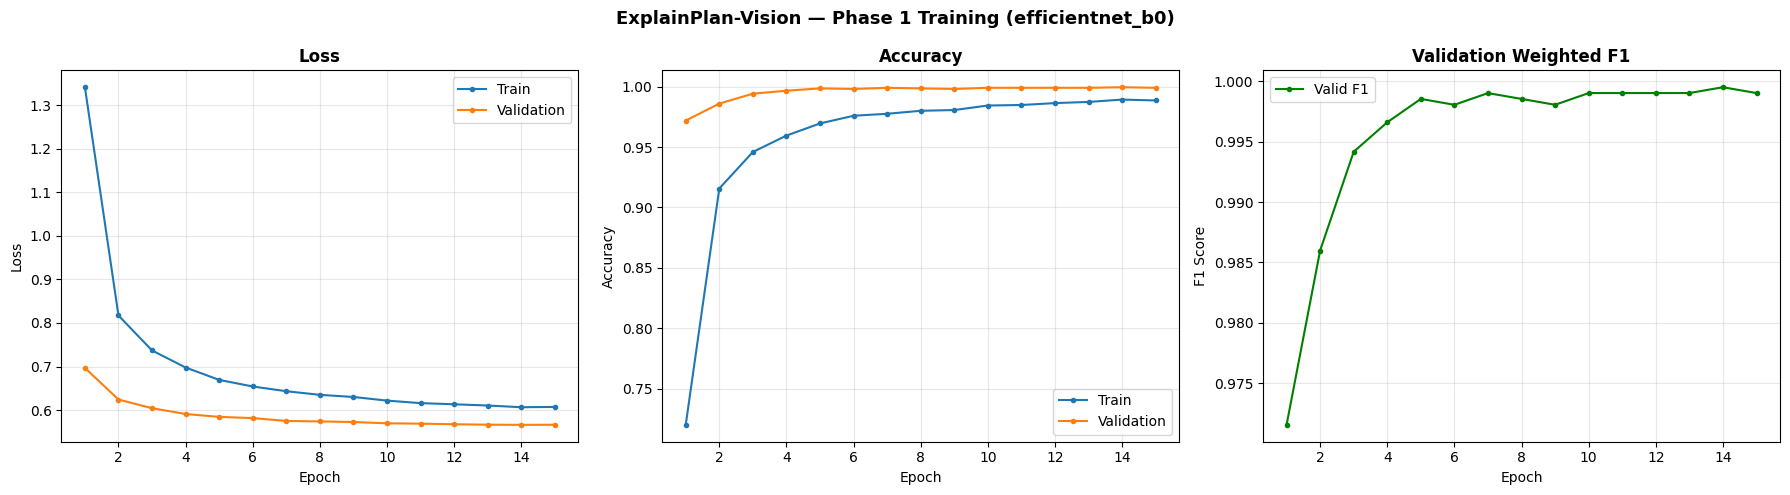

In [31]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(epochs_ran, history["train_loss"], label="Train", marker="o", markersize=3)
axes[0].plot(epochs_ran, history["valid_loss"], label="Validation", marker="o", markersize=3)
axes[0].set_title("Loss", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_ran, history["train_acc"], label="Train", marker="o", markersize=3)
axes[1].plot(epochs_ran, history["valid_acc"], label="Validation", marker="o", markersize=3)
axes[1].set_title("Accuracy", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

# F1
axes[2].plot(epochs_ran, history["valid_f1"], label="Valid F1", color="green", marker="o", markersize=3)
axes[2].set_title("Validation Weighted F1", fontweight="bold")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("F1 Score")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle(f"ExplainPlan-Vision — Phase 1 Training ({CONFIG['model_name']})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CONFIG['log_dir']}/training_curves.png", dpi=150)
plt.show()

---
## Cell 19 — Load Best Checkpoint & Test Set Evaluation

We load the best saved checkpoint and evaluate on the **held-out test set**. The test set has not been seen during training or model selection.

In [1]:
# Load the best checkpoint saved by EarlyStopping.
# weights_only=True is the recommended setting in PyTorch 2.x; it prevents
# arbitrary code execution during deserialization.
model.load_state_dict(
    torch.load(checkpoint_path, map_location=CONFIG["device"], weights_only=True)
)
print(f"Best checkpoint loaded from {checkpoint_path}")

test_loss, test_acc, test_f1, test_preds, test_labels = validate(
    model, test_loader, criterion, CONFIG["device"]
)

test_precision = precision_score(test_labels, test_preds, average="weighted", zero_division=0)
test_recall    = recall_score(test_labels, test_preds, average="weighted", zero_division=0)

print("\n" + "=" * 50)
print("  TEST SET RESULTS")
print("=" * 50)
print(f"  Loss      : {test_loss:.4f}")
print(f"  Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Precision : {test_precision:.4f}")
print(f"  Recall    : {test_recall:.4f}")
print(f"  F1 Score  : {test_f1:.4f}")
print("=" * 50)

Best checkpoint loaded from outputs/checkpoints/best_model.pth


  Valid:   0%|          | 0/65 [00:00<?, ?it/s]


  TEST SET RESULTS
  Loss      : 0.5700
  Accuracy  : 0.9976  (99.76%)
  Precision : 0.9976
  Recall    : 0.9976
  F1 Score  : 0.9976


---
## Cell 20 — Per-Class Classification Report

A per-class breakdown is required for honest research evaluation. Aggregate accuracy hides poor performance on individual disease classes.

In [33]:
report = classification_report(
    test_labels, test_preds,
    target_names=classes,
    zero_division=0
)
print(report)

# ── Save to file ──────────────────────────────────────────────────────────────
with open(f"{CONFIG['log_dir']}/classification_report.txt", "w") as f:
    f.write(report)
print(f"Report saved to {CONFIG['log_dir']}/classification_report.txt")

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       1.00      1.00      1.00       100
                     Pepper__bell___healthy       0.99      0.99      0.99       148
                      Potato___Early_blight       1.00      1.00      1.00       100
                       Potato___Late_blight       1.00      1.00      1.00       100
                           Potato___healthy       1.00      1.00      1.00        15
                      Tomato_Bacterial_spot       1.00      1.00      1.00       213
                        Tomato_Early_blight       0.99      1.00      1.00       100
                         Tomato_Late_blight       1.00      1.00      1.00       191
                           Tomato_Leaf_Mold       1.00      1.00      1.00        95
                  Tomato_Septoria_leaf_spot       1.00      1.00      1.00       177
Tomato_Spider_mites_Two_spotted_spider_mite       0.99      0.99

---
## Cell 21 — Confusion Matrix

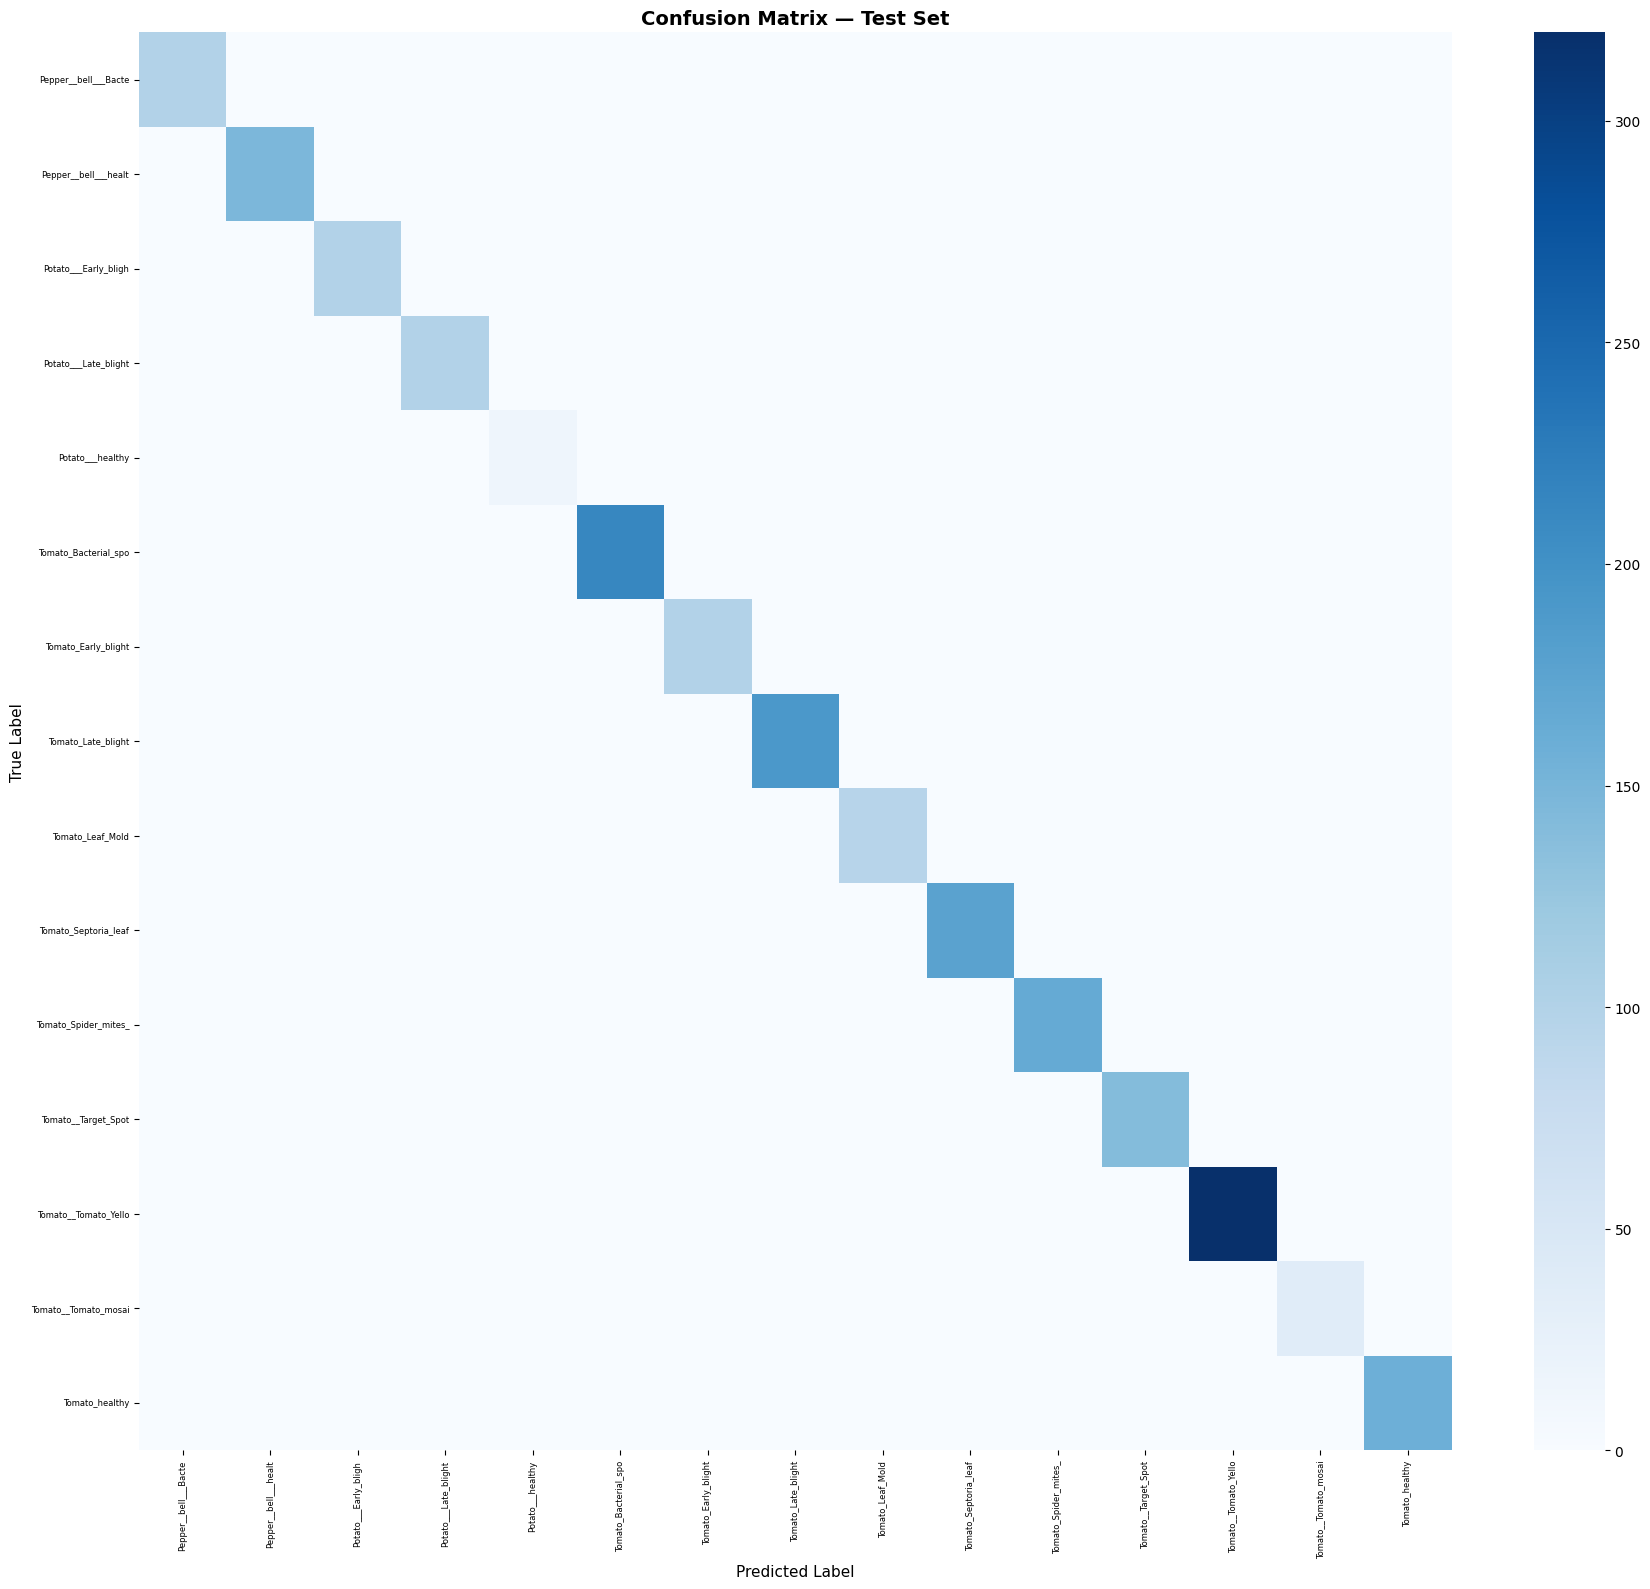

In [34]:
cm_array = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    cm_array, annot=False, fmt="d", cmap="Blues",
    xticklabels=[c[:20] for c in classes],
    yticklabels=[c[:20] for c in classes],
    ax=ax
)
ax.set_title("Confusion Matrix — Test Set", fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.savefig(f"{CONFIG['log_dir']}/confusion_matrix.png", dpi=150)
plt.show()

---
## Cell 22 — Inference Pipeline

This is the **most important module for Phase 3 integration**. The inference engine:

1. Accepts a raw image path
2. Returns a fully **structured prediction dictionary**
3. Includes a **heuristic severity score** based on confidence
4. Returns the **feature embedding** for downstream planning and explainability

The planner in Phase 3 consumes exactly this output format.

In [35]:
def estimate_severity(confidence: float, config: dict) -> str:
    """
    Heuristic severity estimation based on model confidence.

    This is an intentionally simple proxy: higher model certainty correlates
    with more visually pronounced disease symptoms in the PlantVillage dataset.
    Phase 3 will replace this with a segmentation-based lesion-area estimator.
    """
    thresholds = config["severity_thresholds"]
    if confidence >= thresholds["high"]:
        return "high"
    elif confidence >= thresholds["medium"]:
        return "medium"
    else:
        return "low"


def predict(image_path: str, model: nn.Module, config: dict) -> dict:
    """
    End-to-end inference for a single image.

    Parameters
    ----------
    image_path : absolute or relative path to the input image.
    model      : trained PlantDiseaseModel in eval mode.
    config     : global CONFIG dictionary.

    Returns
    -------
    A dictionary with the following keys:
        disease          - full predicted class label
        plant            - plant type parsed from the label
        disease_type     - disease name parsed from the label
        confidence       - float in [0, 1]
        severity         - "high", "medium", or "low"
        top3_predictions - list of dicts for the top 3 predictions
        feature_embedding- numpy array of shape (backbone_out,)
        is_healthy       - boolean
    """
    model.eval()
    device = config["device"]

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    transformed = valid_transforms(image=image)
    tensor      = transformed["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        with autocast("cuda", enabled=config["mixed_precision"]):
            logits, features = model(tensor)
        probs = torch.softmax(logits.float(), dim=1)[0]

    top_idx    = probs.argmax().item()
    confidence = probs[top_idx].item()
    label_name = idx_to_class[top_idx]

    # Parse plant and disease from the label using the same logic as the
    # DataFrame builder so that the two are always consistent.
    if "___" in label_name:
        parts        = label_name.split("___", 1)
        plant        = parts[0].replace("_", " ").strip()
        disease_type = parts[1].replace("_", " ").strip()
    else:
        tokens       = label_name.split("_")
        plant        = tokens[0].strip()
        disease_type = " ".join(tokens[1:]).strip() if len(tokens) > 1 else label_name

    top3_vals, top3_idxs = torch.topk(probs, k=min(3, NUM_CLASSES))
    top3 = [
        {"class": idx_to_class[i.item()], "confidence": round(v.item(), 4)}
        for v, i in zip(top3_vals, top3_idxs)
    ]

    return {
        "disease"          : label_name,
        "plant"            : plant,
        "disease_type"     : disease_type,
        "confidence"       : round(confidence, 4),
        "severity"         : estimate_severity(confidence, config),
        "top3_predictions" : top3,
        "feature_embedding": features[0].cpu().float().numpy(),
        "is_healthy"       : "healthy" in label_name.lower()
    }


print("Inference pipeline ready")

Inference pipeline ready


---
## Cell 23 — Live Inference Demo

We run the inference pipeline on 5 random test images and display the structured output. This simulates the exact API response the Phase 3 planner will consume.


Sample 1:
{
  "disease": "Tomato_healthy",
  "plant": "Tomato",
  "disease_type": "healthy",
  "confidence": 0.9026,
  "severity": "high",
  "top3_predictions": [
    {
      "class": "Tomato_healthy",
      "confidence": 0.9026
    },
    {
      "class": "Tomato_Late_blight",
      "confidence": 0.0089
    },
    {
      "class": "Pepper__bell___healthy",
      "confidence": 0.0082
    }
  ],
  "is_healthy": true
}
  feature_embedding shape: (1280,)

Sample 2:
{
  "disease": "Pepper__bell___Bacterial_spot",
  "plant": "Pepper  bell",
  "disease_type": "Bacterial spot",
  "confidence": 0.9298,
  "severity": "high",
  "top3_predictions": [
    {
      "class": "Pepper__bell___Bacterial_spot",
      "confidence": 0.9298
    },
    {
      "class": "Tomato_Septoria_leaf_spot",
      "confidence": 0.0076
    },
    {
      "class": "Tomato__Tomato_YellowLeaf__Curl_Virus",
      "confidence": 0.007
    }
  ],
  "is_healthy": false
}
  feature_embedding shape: (1280,)

Sample 3:
{
  "disea

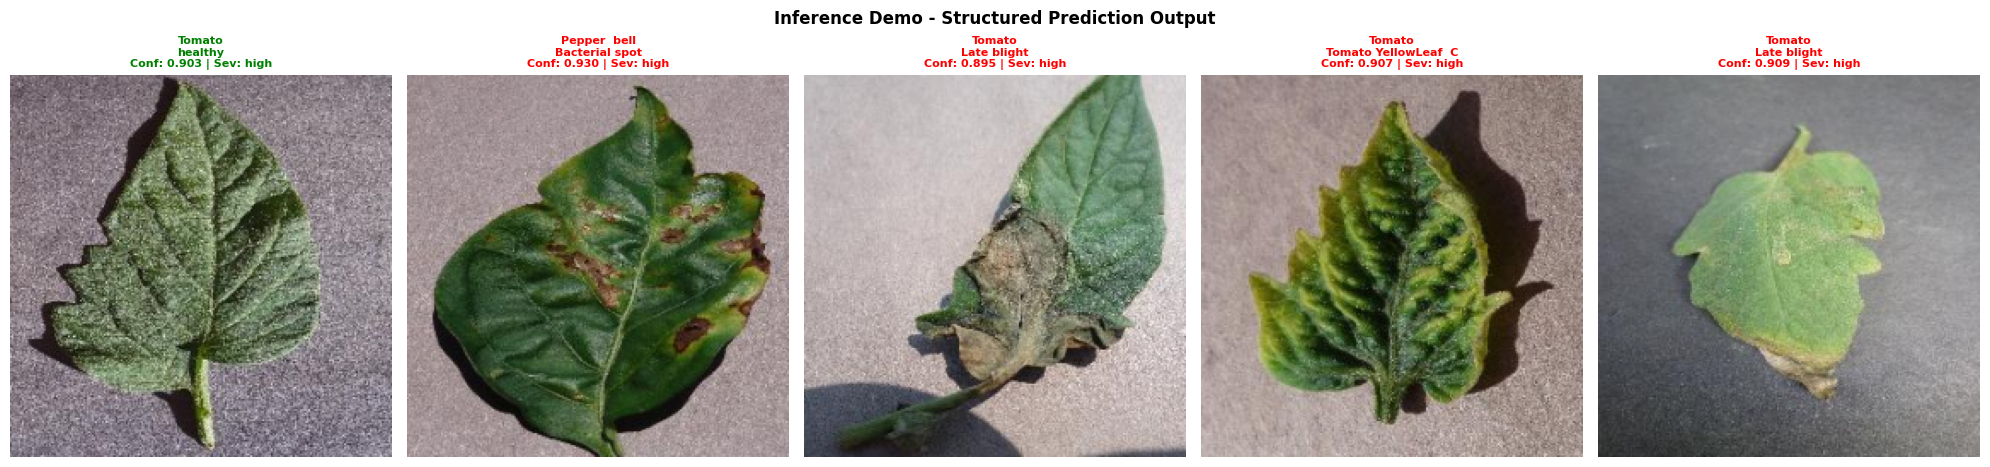

In [36]:
import os
os.makedirs(CONFIG["prediction_dir"], exist_ok=True)

sample_paths = test_df["image_path"].sample(5, random_state=42).tolist()

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, (path, ax) in enumerate(zip(sample_paths, axes)):

    result = predict(path, model, CONFIG)

    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    ax.imshow(img)

    title = (
        f"{result['plant']}\n"
        f"{result['disease_type'][:20]}\n"
        f"Conf: {result['confidence']:.3f} | Sev: {result['severity']}"
    )
    color = "red" if not result["is_healthy"] else "green"
    ax.set_title(title, fontsize=8, color=color, fontweight="bold")
    ax.axis("off")

    print(f"\nSample {i+1}:")
    print(json.dumps({k: v for k, v in result.items() if k != "feature_embedding"}, indent=2))
    print(f"  feature_embedding shape: {result['feature_embedding'].shape}")

plt.suptitle("Inference Demo - Structured Prediction Output", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CONFIG['prediction_dir']}/inference_demo.png", dpi=150)
plt.show()

---
## Cell 24 — Feature Embedding Analysis

We extract embeddings for the test set and visualise them with t-SNE. Well-separated clusters indicate the model has learned meaningful disease representations — a prerequisite for case-based reasoning in Phase 3.

Extracting embeddings:   0%|          | 0/16 [00:00<?, ?it/s]

Embedding matrix shape: (1000, 1280)
Running t-SNE (this may take 1-2 minutes)...


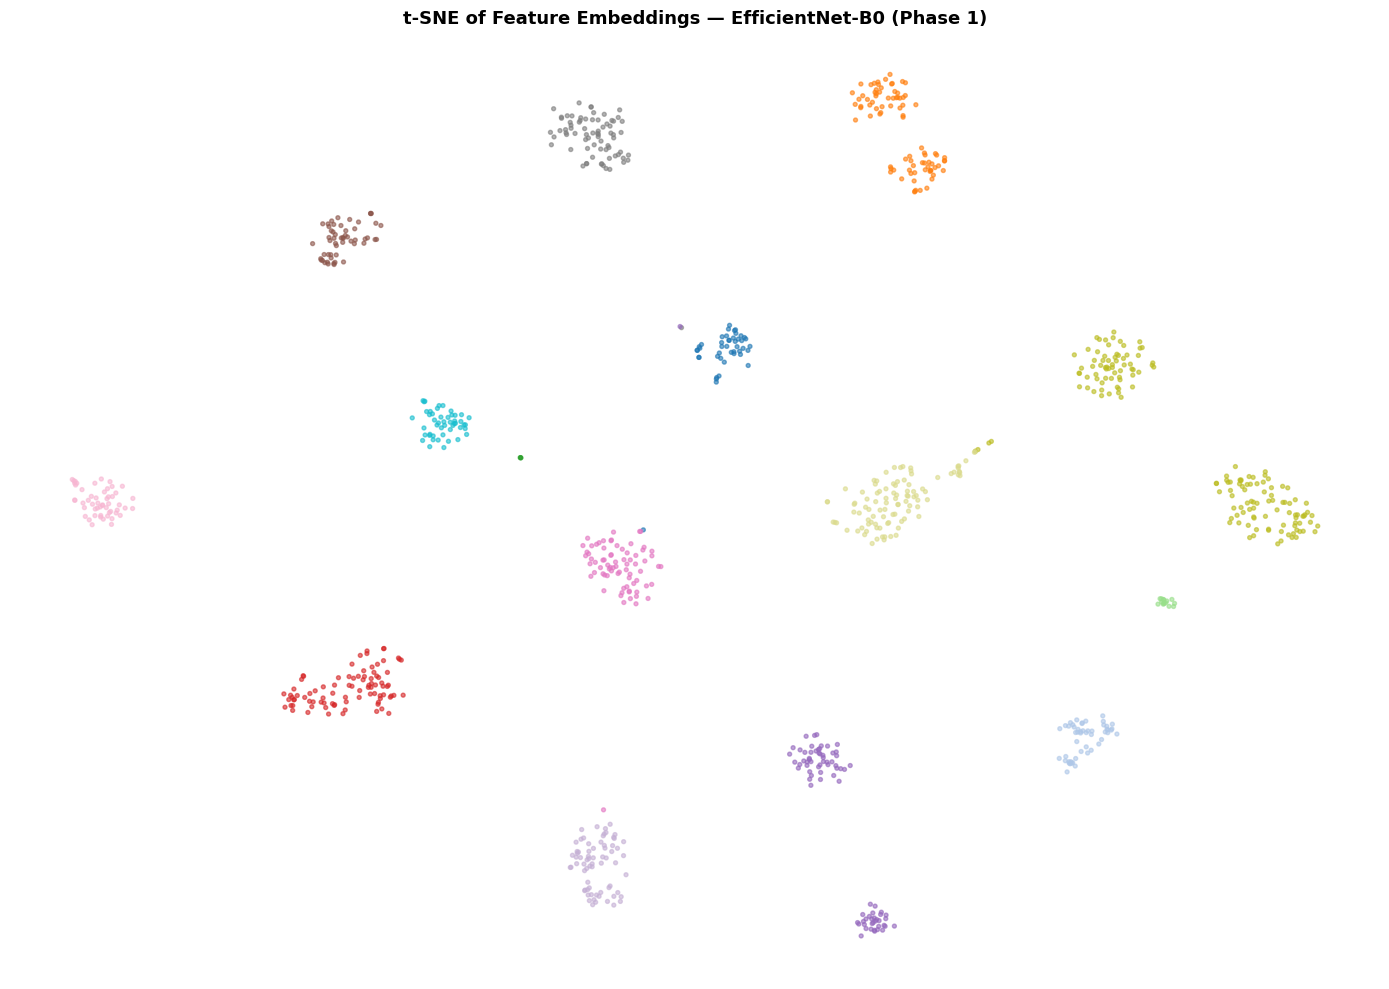

t-SNE plot saved


In [37]:
from sklearn.manifold import TSNE

# ── Extract embeddings for a subset (t-SNE is slow on full test set) ──────────
subset_df    = test_df.sample(min(1000, len(test_df)), random_state=42).reset_index(drop=True)
subset_ds    = PlantDiseaseDataset(subset_df, transforms=valid_transforms)
subset_loader = DataLoader(subset_ds, batch_size=64, shuffle=False, num_workers=2)

all_embeds, all_labels_names = [], []

model.eval()
with torch.no_grad():
    for batch in tqdm(subset_loader, desc="Extracting embeddings"):
        images = batch["image"].to(CONFIG["device"])
        _, feats = model(images)
        all_embeds.append(feats.cpu().numpy())
        all_labels_names.extend(batch["label_name"])

embed_matrix = np.concatenate(all_embeds, axis=0)  # (N, backbone_out)

print(f"Embedding matrix shape: {embed_matrix.shape}")

# ── t-SNE reduction ───────────────────────────────────────────────────────────
print("Running t-SNE (this may take 1-2 minutes)...")
tsne   = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
coords = tsne.fit_transform(embed_matrix)

# ── Plot ──────────────────────────────────────────────────────────────────────
unique_labels = list(set(all_labels_names))
color_map     = {lbl: cm.tab20(i / len(unique_labels)) for i, lbl in enumerate(unique_labels)}
colors        = [color_map[lbl] for lbl in all_labels_names]

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(coords[:, 0], coords[:, 1], c=colors, alpha=0.6, s=8)
ax.set_title("t-SNE of Feature Embeddings — EfficientNet-B0 (Phase 1)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.axis("off")
plt.tight_layout()
plt.savefig(f"{CONFIG['log_dir']}/tsne_embeddings.png", dpi=150)
plt.show()
print("t-SNE plot saved")

---
## Cell 25 — Save All Artefacts

We save everything needed for:
- Phase 2 (class names, config, model)
- Hugging Face deployment (model + metadata)
- GitHub reproducibility (config JSON)

In [38]:
# ── Save class mappings ───────────────────────────────────────────────────────
mappings = {
    "class_to_idx" : class_to_idx,
    "idx_to_class" : {str(k): v for k, v in idx_to_class.items()},
    "num_classes"  : NUM_CLASSES,
    "classes"      : classes
}
with open(f"{CONFIG['checkpoint_dir']}/class_mappings.json", "w") as f:
    json.dump(mappings, f, indent=2)

# ── Save config ───────────────────────────────────────────────────────────────
config_to_save = {k: v for k, v in CONFIG.items() if not callable(v)}
with open(f"{CONFIG['checkpoint_dir']}/config.json", "w") as f:
    json.dump(config_to_save, f, indent=2)

# ── Save training history ─────────────────────────────────────────────────────
with open(f"{CONFIG['log_dir']}/training_history.json", "w") as f:
    json.dump(history, f, indent=2)

# ── Save test results summary ─────────────────────────────────────────────────
test_summary = {
    "model"         : CONFIG["model_name"],
    "test_accuracy" : round(test_acc, 4),
    "test_f1"       : round(test_f1, 4),
    "test_precision": round(test_precision, 4),
    "test_recall"   : round(test_recall, 4),
    "test_loss"     : round(test_loss, 4),
    "best_valid_f1" : round(early_stopping.best_score, 4)
}
with open(f"{CONFIG['log_dir']}/test_results.json", "w") as f:
    json.dump(test_summary, f, indent=2)

print("All artefacts saved")
print()
for root, dirs, files in os.walk("outputs"):
    level = root.replace("outputs", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 2 * (level + 1)
    for file in files:
        print(f"{subindent}{file}")

All artefacts saved

outputs/
  logs/
    training_history.json
    classification_report.txt
    test_results.json
    class_distribution.png
    tsne_embeddings.png
    sample_batch.png
    confusion_matrix.png
    training_curves.png
  checkpoints/
    best_model.pth
    class_mappings.json
    config.json
  predictions/
    inference_demo.png


---
## Cell 26 — Phase 1 Summary & Bridge to Phase 2

### Results Summary

| Metric | Value |
|--------|-------|
| Model | EfficientNet-B0 |
| Dataset | PlantVillage |
| Test Accuracy | *See outputs/logs/test_results.json* |
| Weighted F1 | *See outputs/logs/test_results.json* |
| Checkpoint | outputs/checkpoints/best_model.pth |

### What Phase 1 Delivers to Phase 2

```
predict(image_path)  →  {
    "disease"           : "Tomato___Early_blight",
    "plant"             : "Tomato",
    "disease_type"      : "Early blight",
    "confidence"        : 0.91,
    "severity"          : "high",
    "top3_predictions"  : [...],
    "feature_embedding" : array(shape=(1280,)),
    "is_healthy"        : False
}
```

### Phase 2 Preview — Explainability Layer

Phase 2 will attach the following to this foundation:

- **Grad-CAM** — visual heatmap showing *which pixels drove the classification*
- **SHAP** — feature attribution over the embedding
- **Confidence explanation** — *"High confidence because lesion texture strongly matches training samples"*
- **Why-not explanation** — *"Bacterial spot excluded because lesion edges are dry, not water-soaked"*

### Phase 3 Preview — Planning Engine

Phase 3 will use the structured output above as input to a rule-based planner that outputs:

```
[
    "Step 1: Apply copper-based fungicide",
    "Step 2: Remove and destroy infected leaves",
    "Step 3: Reduce overhead irrigation",
    "Step 4: Monitor for 5 days"
]
```

---
> **GitHub note:** Commit this notebook as `notebooks/phase1_vision_foundation.ipynb`. Create a `notebooks/phase2_explainability.ipynb` in the next phase rather than modifying this file. Each notebook should be independently reproducible.